In [1]:
# kaggle data loading the data from the compitaion
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle competitions download -c playground-series-s6e8

100% 19.7M/19.7M [00:00<00:00, 187MB/s]



In [3]:
# unzip
!unzip playground-series-s6e8.zip

Archive:  playground-series-s6e8.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [4]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
# data loading
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [78]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Start with a fresh reload of train data (ensures consistency)
train = pd.read_csv('/content/train.csv')

# 2. Handle missing values and initial type conversions
id_col_data = train['id']
addicted_label_data = train['addicted_label']

train_features_only = train.drop(columns=['id', 'addicted_label'])

# Define imputation strategies and columns, ensuring correct types
mode_cols = ['gender', 'stress_level', 'academic_work_impact']
median_cols = ['social_media_hours', 'notifications_per_day', 'app_opens_per_day']
mean_cols = ['age', 'daily_screen_time_hours', 'gaming_hours', 'sleep_hours', 'work_study_hours', 'weekend_screen_time']

# Convert weekend_screen_time, age to float if they aren't already for mean imputation
train_features_only['weekend_screen_time'] = train_features_only['weekend_screen_time'].astype(float)
train_features_only['age'] = train_features_only['age'].astype(float)

imputer_transformer = ColumnTransformer(transformers=[
    ('mode_imputer', SimpleImputer(strategy='most_frequent'), mode_cols),
    ('median_imputer', SimpleImputer(strategy='median'), median_cols),
    ('mean_imputer', SimpleImputer(strategy='mean'), mean_cols)
], remainder='passthrough')

train_imputed_array = imputer_transformer.fit_transform(train_features_only)

processed_feature_names = mode_cols + median_cols + mean_cols
train_processed_df = pd.DataFrame(train_imputed_array, columns=processed_feature_names, index=train_features_only.index)

# Ensure numeric columns are float after imputation
for col in median_cols + mean_cols:
    train_processed_df[col] = train_processed_df[col].astype(float)

# 3. Define X and y for final preprocessing and model training
X_full = train_processed_df.copy()
y = addicted_label_data.astype(int)

# 4. Apply Encoding and Scaling
final_categorical_features = mode_cols
final_numeric_features = median_cols + mean_cols

preprocessor_final = ColumnTransformer(
    transformers=[
        ('cat_encoder', OrdinalEncoder(), final_categorical_features),
        ('num_scaler', StandardScaler(), final_numeric_features)
    ],
    remainder='passthrough' # Keep other columns if any, though none expected after full definition
)

X_processed_scaled_array = preprocessor_final.fit_transform(X_full)

encoded_cat_names = [f'encoded_{col}' for col in final_categorical_features]
final_transformed_feature_names = encoded_cat_names + final_numeric_features

X = pd.DataFrame(X_processed_scaled_array, columns=final_transformed_feature_names, index=X_full.index)

print("Comprehensive Preprocessing Complete:")
print("Processed X info:")
print(X.info())
print("\nTarget y info:")
print(y.info())

# 5. Perform Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Comprehensive Preprocessing Complete:
Processed X info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   encoded_gender                691369 non-null  float64
 1   encoded_stress_level          691369 non-null  float64
 2   encoded_academic_work_impact  691369 non-null  float64
 3   social_media_hours            691369 non-null  float64
 4   notifications_per_day         691369 non-null  float64
 5   app_opens_per_day             691369 non-null  float64
 6   age                           691369 non-null  float64
 7   daily_screen_time_hours       691369 non-null  float64
 8   gaming_hours                  691369 non-null  float64
 9   sleep_hours                   691369 non-null  float64
 10  work_study_hours              691369 non-null  float64
 11  weekend_screen_time           691369 non-null  f

In [68]:
# This cell's logic has been moved to zz90Rlvo--PW for comprehensive preprocessing.

In [69]:
# This cell's logic has been moved to zz90Rlvo--PW for comprehensive preprocessing.

In [29]:
train_trans.shape

(691369, 12)

In [57]:
X = train_trans
y = train.iloc[:,-1].astype(int) # Convert target to integer type

In [77]:
# The train_test_split logic has been moved to zz90Rlvo--PW for comprehensive preprocessing.

In [59]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
# plotting roc - auc
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

Random Forest Classifier Evaluation:

ROC AUC Score: 0.9412

Confusion Matrix:
[[ 49619  16684]
 [ 13032 148817]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77     66303
           1       0.90      0.92      0.91    161849

    accuracy                           0.87    228152
   macro avg       0.85      0.83      0.84    228152
weighted avg       0.87      0.87      0.87    228152



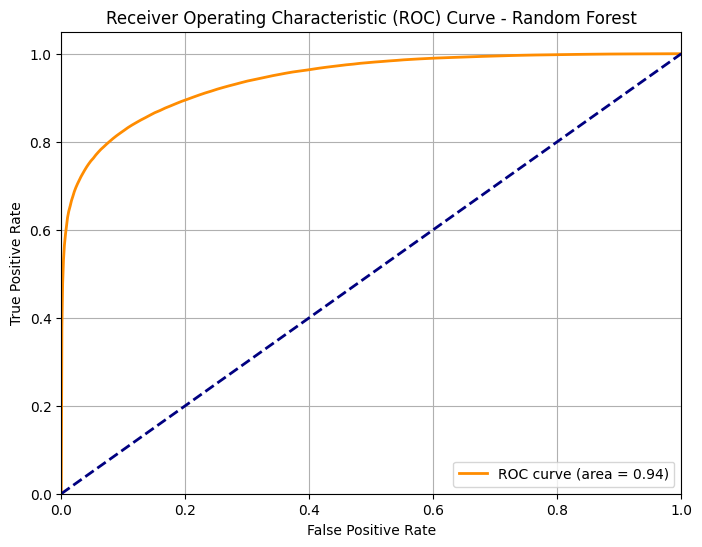

In [61]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
print("Random Forest Classifier Evaluation:\n")

# ROC AUC Score
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(conf_matrix_rf)

# Classification Report
class_report_rf = classification_report(y_test, y_pred_rf)
print("\nClassification Report:")
print(class_report_rf)

# Plotting ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Bagging Classifier Implementation and Evaluation


Bagging Classifier Evaluation:

ROC AUC Score: 0.9392

Confusion Matrix:
[[ 49275  17028]
 [ 13152 148697]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.74      0.77     66303
           1       0.90      0.92      0.91    161849

    accuracy                           0.87    228152
   macro avg       0.84      0.83      0.84    228152
weighted avg       0.87      0.87      0.87    228152



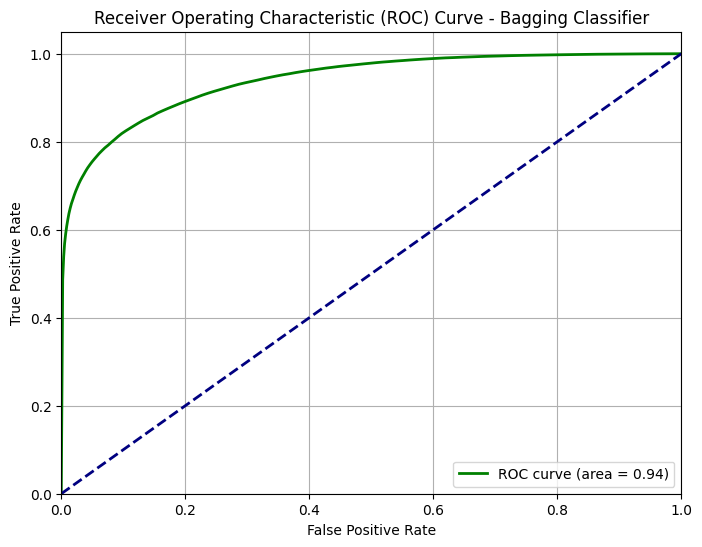

In [66]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(random_state=42)

bagging_model = BaggingClassifier(
    estimator=base_estimator,
    n_estimators=100, # A common number of estimators
    random_state=42,
    n_jobs=-1 # Use all available CPU cores for parallel training
)

# Train the Bagging Classifier
bagging_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_bagging = bagging_model.predict(X_test)
y_pred_proba_bagging = bagging_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the model
print("\nBagging Classifier Evaluation:\n")

# ROC AUC Score
roc_auc_bagging = roc_auc_score(y_test, y_pred_proba_bagging)
print(f"ROC AUC Score: {roc_auc_bagging:.4f}")

# Confusion Matrix
conf_matrix_bagging = confusion_matrix(y_test, y_pred_bagging)
print("\nConfusion Matrix:")
print(conf_matrix_bagging)

# Classification Report
class_report_bagging = classification_report(y_test, y_pred_bagging)
print("\nClassification Report:")
print(class_report_bagging)

# Plotting ROC Curve for Bagging
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_pred_proba_bagging)
plt.figure(figsize=(8, 6))
plt.plot(fpr_bagging, tpr_bagging, color='green', lw=2, label=f'ROC curve (area = {roc_auc_bagging:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Bagging Classifier')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### LightGBM Classifier with 5-Fold Cross-Validation

Starting 5-fold cross-validation for LightGBM...

--- Fold 1/5 ---
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1929
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892589
[LightGBM] [Info] Start training from score 0.892589

--- Fold 2/5 ---
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019845 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1928
[LightGBM] [Info] Numbe

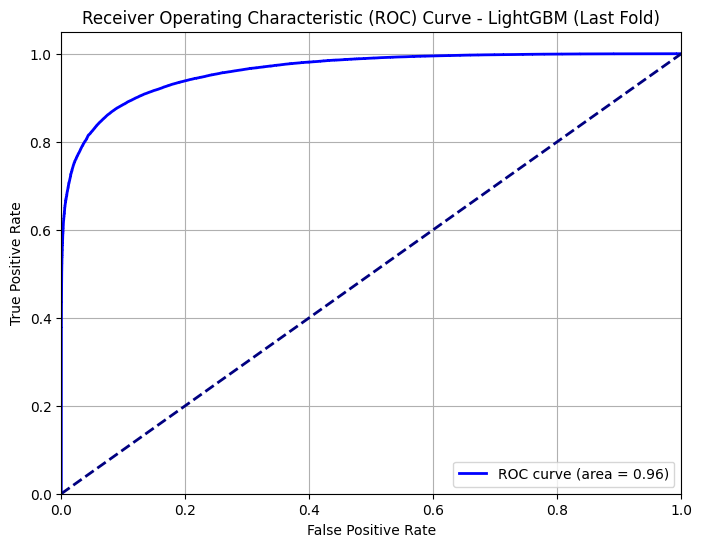

In [80]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Initialize LightGBM Classifier
lgbm_model = lgb.LGBMClassifier(random_state=42, n_estimators=1000, learning_rate=0.05, num_leaves=31, n_jobs=-1)

# Set up Stratified K-Fold Cross-Validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

roc_auc_scores = []
classification_reports = []
confusion_matrices = []
fpr_list = []
tpr_list = []

print(f"Starting {n_splits}-fold cross-validation for LightGBM...")

for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Train the LightGBM model
    lgbm_model.fit(X_train_fold, y_train_fold,
                    eval_set=[(X_val_fold, y_val_fold)],
                    eval_metric='auc',
                    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]) # Early stopping

    # Make predictions on the validation set
    y_pred_fold = lgbm_model.predict(X_val_fold)
    y_pred_proba_fold = lgbm_model.predict_proba(X_val_fold)[:, 1]

    # Evaluate current fold
    fold_roc_auc = roc_auc_score(y_val_fold, y_pred_proba_fold)
    roc_auc_scores.append(fold_roc_auc)

    fold_conf_matrix = confusion_matrix(y_val_fold, y_pred_fold)
    confusion_matrices.append(fold_conf_matrix)

    fold_class_report = classification_report(y_val_fold, y_pred_fold, output_dict=True)
    classification_reports.append(fold_class_report)

    # Store ROC curve for plotting (e.g., from the last fold, or average later)
    if fold == n_splits - 1: # Just taking the last fold's ROC for now
        fpr_lgbm, tpr_lgbm, _ = roc_curve(y_val_fold, y_pred_proba_fold)
        fpr_list.append(fpr_lgbm)
        tpr_list.append(tpr_lgbm)

print("\n--- Overall LightGBM Evaluation (5-Fold CV) ---")
print(f"Average ROC AUC: {np.mean(roc_auc_scores):.4f} (+/- {np.std(roc_auc_scores):.4f})")

# Display classification report and confusion matrix from the last fold for example
print("\nClassification Report (Last Fold):\n")
print(classification_reports[-1])

print("\nConfusion Matrix (Last Fold):\n")
print(confusion_matrices[-1])

# Plotting ROC Curve from the last fold
plt.figure(figsize=(8, 6))
plt.plot(fpr_list[-1], tpr_list[-1], color='blue', lw=2, label=f'ROC curve (area = {roc_auc_scores[-1]:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - LightGBM (Last Fold)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import lightgbm as lgb

# 1. Load the raw test data
test = pd.read_csv('/content/test.csv')

# Keep original test IDs for submission file
test_ids = test['id']

# Drop 'id' from test data before preprocessing
test_features_only = test.drop(columns=['id'])

# 2. Apply the *fitted* imputation transformer to the test data
#    (imputer_transformer was fitted on train_features_only in cell zz90Rlvo--PW)

test_imputed_array = imputer_transformer.transform(test_features_only)

# Reconstruct the DataFrame after imputation (using the same column names as processed_feature_names)
test_processed_df = pd.DataFrame(test_imputed_array, columns=processed_feature_names, index=test_features_only.index)

# Ensure numeric columns are float after imputation for the test set
for col in median_cols + mean_cols:
    test_processed_df[col] = test_processed_df[col].astype(float)

# 3. Apply the *fitted* final preprocessor (encoding + scaling) to the test data
#    (preprocessor_final was fitted on X_full in cell zz90Rlvo--PW)

X_test_processed_scaled_array = preprocessor_final.transform(test_processed_df)

# Reconstruct X_test_processed as a DataFrame
X_test_submission = pd.DataFrame(X_test_processed_scaled_array, columns=final_transformed_feature_names, index=test_processed_df.index)

print("Test Data Preprocessing Complete:")
print(X_test_submission.info())

# 4. Retrain the LightGBM model on the *entire* training dataset (X and y)
#    The lgbm_model object was already defined and configured earlier.
#    We fit it on the full X and y to make best use of all training data for final predictions.
print("\nRetraining LightGBM model on full training data...")
final_lgbm_model = lgb.LGBMClassifier(random_state=42, n_estimators=1000, learning_rate=0.05, num_leaves=31, n_jobs=-1)
final_lgbm_model.fit(X, y)
print("LightGBM model retraining complete.")

# 5. Make predictions (probabilities) on the preprocessed test data
submission_probabilities = final_lgbm_model.predict_proba(X_test_submission)[:, 1]

# 6. Create the submission DataFrame
submission_df = pd.DataFrame({'id': test_ids, 'addicted_label': submission_probabilities})

# 7. Save the submission file
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"\nSubmission file '{submission_filename}' created successfully.")
print("First 5 rows of the submission file:")
print(submission_df.head())

Test Data Preprocessing Complete:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296302 entries, 0 to 296301
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   encoded_gender                296302 non-null  float64
 1   encoded_stress_level          296302 non-null  float64
 2   encoded_academic_work_impact  296302 non-null  float64
 3   social_media_hours            296302 non-null  float64
 4   notifications_per_day         296302 non-null  float64
 5   app_opens_per_day             296302 non-null  float64
 6   age                           296302 non-null  float64
 7   daily_screen_time_hours       296302 non-null  float64
 8   gaming_hours                  296302 non-null  float64
 9   sleep_hours                   296302 non-null  float64
 10  work_study_hours              296302 non-null  float64
 11  weekend_screen_time           296302 non-null  float64
dtypes: float64